In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing_extensions import TypedDict
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
model = ChatGroq(model="openai/gpt-oss-20b")

In [4]:
# define state
class BlogState(TypedDict):
    title: str
    outline: str
    content: str


In [6]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title from state
    title = state['title']

    # call llm and generate outline
    prompt = f"Create a detailed outline for a blog post for the following title: {title}"
    outline = model.invoke(prompt).content

    # update state
    state["outline"] = outline

    return state

In [20]:
def create_blog(state: BlogState) -> BlogState:

    #fetch title and outline from state
    title = state["title"]
    outline = state["outline"]

    # call llm and generate blog content
    prompt = f"Write a blog for me on {title} using the following outline: \n {outline}"
    content = model.invoke(prompt).content

    # update state
    state["content"] = content

    return state

In [21]:
# create graph
graph = StateGraph(BlogState)

# add nodes to the graph
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# add edges to the graph
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

# compile graph

workflow = graph.compile()

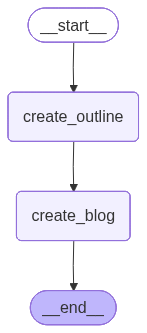

In [22]:
workflow

In [23]:
# execute workflow
initial_state = {"title": "Rise of AI"}

final_state = workflow.invoke(initial_state)

print(final_state)

{'title': 'Rise of AI', 'outline': '## Blog Post Outline  \n**Title:** *Rise of AI: From Sci‑Fi to Everyday Reality*  \n\n---\n\n### 1. Hook & Context (≈150 words)  \n- **A vivid opening anecdote** – e.g., a 2024 household robot that schedules your day.  \n- **Why this matters today** – quick stats (global AI market >$200B, 70% of enterprises adopting AI).  \n- **Thesis statement** – AI is no longer niche; it’s reshaping every industry, culture, and personal experience.\n\n---\n\n### 2. Defining “AI” for the Modern Reader  \n| Section | Content |\n|---------|---------|\n| **2.1 What is AI?** | Simple definition; contrast “Artificial Intelligence” vs. “Machine Learning” vs. “Deep Learning”. |\n| **2.2 A Brief Historical Timeline** | 1950s – Turing Test → 1980s – Expert Systems → 2010s – Neural Nets & Big Data → 2020s – Generative AI & LLMs. |\n| **2.3 Common Misconceptions** | “AI = Robots”, “AI = Sentience”, “AI = Future only”. Provide clarifications with examples. |\n\n---\n\n### 3. P

In [24]:
print(final_state["outline"])

## Blog Post Outline  
**Title:** *Rise of AI: From Sci‑Fi to Everyday Reality*  

---

### 1. Hook & Context (≈150 words)  
- **A vivid opening anecdote** – e.g., a 2024 household robot that schedules your day.  
- **Why this matters today** – quick stats (global AI market >$200B, 70% of enterprises adopting AI).  
- **Thesis statement** – AI is no longer niche; it’s reshaping every industry, culture, and personal experience.

---

### 2. Defining “AI” for the Modern Reader  
| Section | Content |
|---------|---------|
| **2.1 What is AI?** | Simple definition; contrast “Artificial Intelligence” vs. “Machine Learning” vs. “Deep Learning”. |
| **2.2 A Brief Historical Timeline** | 1950s – Turing Test → 1980s – Expert Systems → 2010s – Neural Nets & Big Data → 2020s – Generative AI & LLMs. |
| **2.3 Common Misconceptions** | “AI = Robots”, “AI = Sentience”, “AI = Future only”. Provide clarifications with examples. |

---

### 3. Pillars of the AI Boom  
| Pillar | Key Technologies | Rea

In [25]:
print(final_state["content"])

# Rise of AI: From Sci‑Fi to Everyday Reality  

---

## 1. Hook & Context (≈150 words)

Picture this: it’s 2024, you walk into your kitchen and a sleek, silent robot greets you. “Good morning, Maya. Your schedule today: 9 a.m. – virtual boardroom, 12 p.m. – lunch with the AI‑generated meal planner, 4 p.m. – a quick walk‑through of the smart‑home energy dashboard.” The robot has already pulled in your calendar, the city traffic feed, and the latest weather model to adjust the HVAC, your commute, and even your lunch order—all in real time.  

That scene is no longer a plot point in a science‑fiction film; it’s the new normal. According to IDC, the global AI market surpassed **$200 billion** in 2024, and a **70 %** survey of enterprises worldwide reported that AI has been integrated into at least one core business function.  

**Thesis:** Artificial Intelligence is no longer a niche laboratory curiosity—it’s the engine that’s reshaping every industry, culture, and personal experience we 